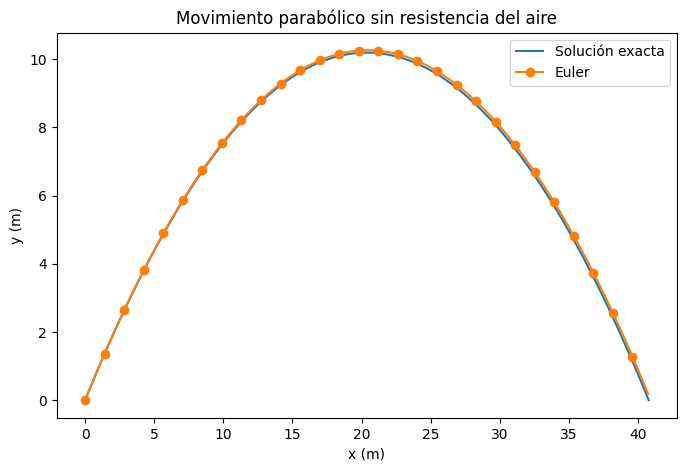

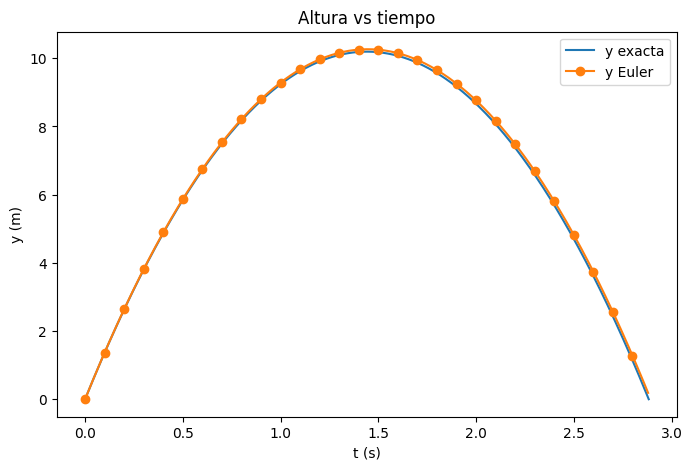

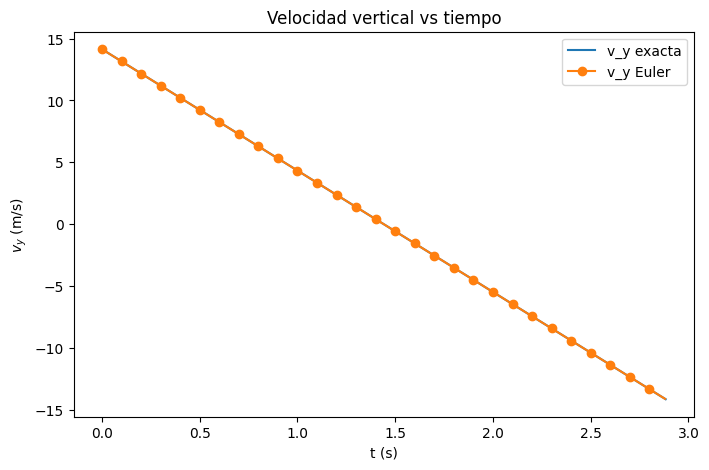

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Parámetros del problema
# -----------------------------
g = 9.81                 # gravedad (m/s^2)
v0 = 20.0                # rapidez inicial (m/s)
theta = np.deg2rad(45)   # ángulo de lanzamiento
x0, y0 = 0.0, 0.0        # posición inicial

vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

# Tiempo total de integración
t_total = 2 * vy0 / g    # tiempo de vuelo aproximado si y0 = 0
dt = 0.01
N = int(t_total / dt) + 1

# -----------------------------
# Arreglos para Euler
# -----------------------------
t_euler = np.zeros(N)
x_euler = np.zeros(N)
y_euler = np.zeros(N)
vx_euler = np.zeros(N)
vy_euler = np.zeros(N)

# Condiciones iniciales
t_euler[0] = 0.0
x_euler[0] = x0
y_euler[0] = y0
vx_euler[0] = vx0
vy_euler[0] = vy0

# -----------------------------
# Integración por Euler
# -----------------------------
for n in range(N - 1):
    t_euler[n+1] = t_euler[n] + dt

    x_euler[n+1] = x_euler[n] + dt * vx_euler[n]
    y_euler[n+1] = y_euler[n] + dt * vy_euler[n]

    vx_euler[n+1] = vx_euler[n]
    vy_euler[n+1] = vy_euler[n] - g * dt

# -----------------------------
# Solución exacta
# -----------------------------
t_exact = np.linspace(0, t_total, 1000)
x_exact = x0 + vx0 * t_exact
y_exact = y0 + vy0 * t_exact - 0.5 * g * t_exact**2
vy_exact = vy0 - g * t_exact

# -----------------------------
# Graficar trayectoria
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(x_exact, y_exact, label='Solución exacta')
plt.plot(x_euler, y_euler, 'o-', markevery=10, label='Euler')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Movimiento parabólico sin resistencia del aire')
plt.legend()
plt.savefig("Trayectoria.pdf", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# Graficar altura en función del tiempo
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(t_exact, y_exact, label='y exacta')
plt.plot(t_euler, y_euler, 'o-', markevery=10, label='y Euler')
plt.xlabel('t (s)')
plt.ylabel('y (m)')
plt.title('Altura vs tiempo')
plt.legend()
plt.savefig("Altura.pdf", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# Graficar velocidad vertical en función del tiempo
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(t_exact, vy_exact, label='v_y exacta')
plt.plot(t_euler, vy_euler, 'o-', markevery=10, label='v_y Euler')
plt.xlabel('t (s)')
plt.ylabel(r'$v_y$ (m/s)')
plt.title('Velocidad vertical vs tiempo')
plt.legend()
plt.savefig("Velocidad_vertical.pdf", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# Descargar archivos
# -----------------------------
files.download("Trayectoria.pdf")
files.download("Altura.pdf")
files.download("Velocidad_vertical.pdf")